In [36]:
import math

In [37]:
Tа_полн = 288   # K
Pа_полн = 1.013 * 10**5  # Па
G_в = 58.7  # кг/с
π_к_полн = 18.2  # Степень повышения давления в компрессоре
n = 8600  # об/мин

R_в = 287.4  # Дж/(кг*К)
k = 1.4  # показатель адиабаты для воздуха
# Дж/(кг*К) удельная теплоемкость при постоянном давлении для воздуха
c_p = 1006

Предварительный расчет проточной части по средней линии тока

In [38]:
# Dk = const

d1_отн = 0.4    # Относительный диаметр втулки первой ступени
c_а1_отн = 0.45   # Коэффициент расхода первой ступени
с_а_отн = 0.3   # Коэффициент расхода для последней ступени примем
Hт_ср_отн = 0.3   # Коэффициент напора в средних ступенях
R_ср1 = 0.5   # Степень реактивности
H_т1 = 0.2   # Коэффициент напора первой ступени

# Первое приближение

In [39]:
n = n / (60 / (2 * math.pi))  # Преобразуем обороты в радианы в секунду
print(f" n = {n}")

 n = 900.589894029074


In [40]:
# Определим адиабатический КПД
η_пол = 0.92 # Политропический КПД компрессора из рис.1
η_к_полн = ((π_к_полн)**((k-1)/k)-1) / ((π_к_полн)**((k-1)/(k*η_пол))-1)

# Пренебрегая теплообменом в трубках:
T1_полн = Tа_полн

# Температура на выходе из ЛА компрессора
Tk_полн = Tа_полн * (1 + ((π_к_полн**((k-1)/k)-1) / η_к_полн))
T2_полн = Tk_полн

# Критическая скорость звука во входном и выходном патрубках
a_кр_вх = math.sqrt((2*k/(k+1))*R_в*Tа_полн)
a_кр_вых = math.sqrt((2*k/(k+1))*R_в*Tk_полн)

# Плотность рабочего тела по заторможенным параметрам
ρ1_полн = Pа_полн / (Tа_полн * R_в)

# Окружная скорость конца рабочей лопатки
U_k1 = math.cbrt((G_в * n**2)/(math.pi * c_а1_отн * ρ1_полн * (1 - d1_отн**2)))
print(f"U_k1 = {U_k1:.2f} м/с")

for i in range(3):      # Цикл для трех приближений
    # Осевая скорость на переферии РК
    c_а1 = c_а1_отн * U_k1

    # Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
    c_вх = U_k1 * c_а1_отн
    c_вых = U_k1 * с_а_отн

    # Приведенные скорости в данных сечениях
    λ_вх = c_вх / a_кр_вх
    λ_вых = c_вых / a_кр_вых

    # Коэффициент потерь полного давления во входном и выходном патрубках
    ξ_вх = 0.05     # Для входного патрубка
    ξ_вых = 0.15    # Для выходного патрубка

    # ГДФ плотности для входного и выходного патрубков
    ε_вх = (1 - (k-1)/(k+1)*λ_вх**2)**(1/(k-1))
    ε_вых = (1 - (k-1)/(k+1)*λ_вых**2)**(1/(k-1))

    # Коэффициенты сохранения полного давления во входном и выходном патрубках
    σ_вх = 1 / (1 + ξ_вх * (k/(k+1)) * ε_вх * λ_вх**2)
    σ_вых = (1 - ξ_вых * (k/(k+1)) * ε_вых * λ_вых**2)

    # Полные давления на входе и выходе из лопаточного аппарата
    P1_полн = σ_вх * Pа_полн

    # Средний радиус на входе в первую степень
    r_ср1_отн = math.sqrt( (1 + d1_отн**2) / 2)

    # Безразмерная окружная составляющая абсолютной скорости на входе
    c_1u_отн = r_ср1_отн * (1 - R_ср1) - (H_т1 / (2 * r_ср1_отн))

    # Абсолютная скорость: 
    c1 = U_k1 * math.sqrt(c_а1_отн**2 + c_1u_отн**2)

    # Приведенная скорость:
    λ1 = c1 / a_кр_вх

    # ГДФ плотности
    ε = (1 - ((k-1)/(k+1)) * λ1**2)**(1/(k-1))

    # Плотность рабочего тела перед РК
    ρ1 = (P1_полн / (R_в * T1_полн)) * ε

    # Перерасчет окружной скорости конца рабочей лопатки
    U_k1 = math.cbrt((G_в * n**2)/(math.pi * c_а1_отн * ρ1 * (1 - d1_отн**2)))
    print(f" u = {U_k1}")

U_k1 = 319.97 м/с
 u = 333.63450245775124
 u = 334.87940394444325
 u = 334.99584567148423


In [41]:
# Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
c_вх = U_k1 * c_а1_отн
c_вых = U_k1 * с_а_отн

# Приведенные скорости в данных сечениях
λ_вх = c_вх / a_кр_вх
λ_вых = c_вых / a_кр_вых

# Коэффициент потерь полного давления во входном и выходном патрубках
ξ_вх = 0.05     # Для входного патрубка
ξ_вых = 0.15    # Для выходного патрубка

# ГДФ плотности для входного и выходного патрубков
ε_вх = (1 - (k-1)/(k+1)*λ_вх**2)**(1/(k-1))
ε_вых = (1 - (k-1)/(k+1)*λ_вых**2)**(1/(k-1))

# Коэффициенты сохранения полного давления во входном и выходном патрубках
σ_вх = 1 / (1 + ξ_вх * (k/(k+1)) * ε_вх * λ_вх**2)
σ_вых = (1 - ξ_вых * (k/(k+1)) * ε_вых * λ_вых**2)

# Полные давления на входе и выходе из лопаточного аппарата
P1_полн = σ_вх * Pа_полн
P2_полн = Pа_полн * π_к_полн / σ_вых

# Степень повышения полного давления лопаточного аппарата
π_ла_полн = P2_полн / P1_полн
π_к_полн = π_ла_полн * (σ_вых * σ_вх)

# КПД лопаточного аппарата
η_ла = σ_вых * σ_вх  # Должно быть 1

# Коэффициент C определяется из графика на рис. 7
C = 0.98  # Надо написать функцию для определения C по графику, а не брать константное значение
# !!!!!!!!
# !!!!!!!!

η_ла_полн = η_к_полн / C
η_к_полн = η_ла_полн * ((π_к_полн**((k-1)/k)-1)/(π_ла_полн**((k-1)/k)-1))


β = math.sqrt((2*k)/(k+1)) * (2 / (k+1))**(1/(k-1))

# Приведенная плотность потока массы
q_вх = ((k+1)/2)**(1/(k-1)) * λ_вх * (1 - (k-1)/(k+1)*λ_вх**2)**(1/(k-1))
q_вых = ((k+1)/2)**(1/(k-1)) * λ_вых * (1 - (k-1)/(k+1)*λ_вых**2)**(1/(k-1))
# Кольцевые площади на выходе из входного патрубка и на входе в выходной патрубок
F_вх = (G_в * math.sqrt(R_в * T1_полн)) / (β * P1_полн * q_вх)
F_вых = (G_в * math.sqrt(R_в * T2_полн)) / (β * P2_полн * q_вых)

# Наружный диаметр ротора:
D_к1 = 2 * U_k1 / n

# Внутренний диаметр
D_вт1 = D_к1 * d1_отн

# Средний диаметр
D_ср1 = D_к1 * r_ср1_отн

# Высота лопатки РК 1-й ступени:
h_1 = (1/2) * D_к1 * (1 - d1_отн)

# Диаметр втулки лопаток последнйей ступени:
D_вт_n = math.sqrt(D_к1**2 - ((4 * F_вых) / math.pi))

# Относительный диаметр втулки рабочего колеса последней ступени:
d_n_отн = D_вт_n / D_к1

# Высота лопаток последней ступени:
h_n = (1/2) * D_к1 * (1 - d_n_отн)

# Окружная скорость концов рабочих лопаток "средней" ступени:
# Теоретический напор "средней" ступени:
Hт_ср = Hт_ср_отн * (U_k1**2)

# Адиабатический напор компрессора по параметрам затарможенного потока
H_ад_к_полн = (k*R_в)/(k-1) * Tа_полн*((π_к_полн ** ((k-1)/k))-1)

# Сумма теоретических напоров по ступеням:
H_тк = H_ад_к_полн / η_к_полн

# Число ступеней компрессора:
z = H_тк / Hт_ср
print(f"z = {z} Не округленное")

z = math.ceil(z)
print(f"z = {z}")

z = 12.392299547954384 Не округленное
z = 13


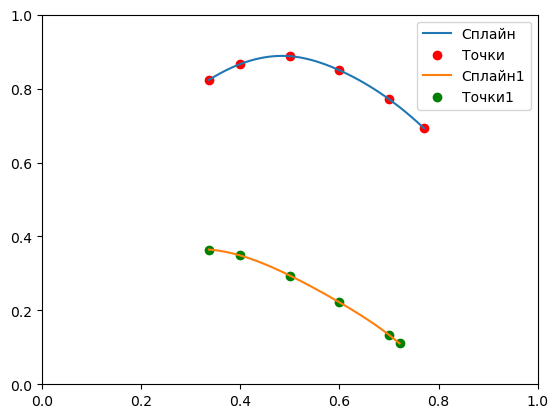

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# Ваши точки
x = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.770588235294])
y = np.array([0.82371541502, 0.866403, 0.88774703, 0.849604743, 0.771343873, 0.692490118577])

x1 = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.721379310345])
y1 = np.array([0.36446601942, 0.34854368932, 0.294174757282, 0.221747572816, 0.13360824742, 0.11038026721])

# Создаем более плотную сетку X для плавности
x_smooth = np.linspace(x.min(), x.max(), 300)
spline = make_interp_spline(x, y, k=3) # k=3 — кубический сплайн
y_smooth = spline(x_smooth)

x1_smooth = np.linspace(x1.min(), x1.max(), 300)
spline = make_interp_spline(x1, y1, k=3) # k=3 — кубический сплайн
y1_smooth = spline(x1_smooth)

plt.plot(x_smooth, y_smooth, label='Сплайн')
plt.scatter(x, y, color='red', label='Точки')
plt.plot(x1_smooth, y1_smooth, label='Сплайн1')
plt.scatter(x1, y1, color='green', label='Точки1')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.show()
